<a href="https://colab.research.google.com/github/IrumShehryar/ML-NLP-Coursework/blob/main/ml/06-neural-network-for-classification/Project_05_NN_HAR_Hetrodata_FeatureExtraction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader,TensorDataset
from sklearn.model_selection import train_test_split
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import style
style.use('dark_background')
import pandas as pd

In [2]:
torch.cuda.is_available()

True

In [3]:
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print(device)

cuda:0


In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
%cd /content/drive/MyDrive/ML-course/Course Material/Supervised Machine Learning/Neural Networks for Classification

/content/drive/MyDrive/ML-course/Course Material/Supervised Machine Learning/Neural Networks for Classification


In [6]:
data = pd.read_csv('Heterogeneous_accelerometer_HAR.csv')
data.shape

(3540962, 10)

In [7]:
data.head()

,Index,Arrival_Time,Creation_Time,x,y,z,User,Model,Device,gt
0,0,1424696638740,27920678471000,-0.565032,-9.572019,-0.614113,a,gear,gear_1,stand
1,1,1424696638740,27920681910000,-0.832584,-9.713276,-0.606930,a,gear,gear_1,stand
2,2,1424696638740,27920692014000,-1.018134,-9.935339,-0.544082,a,gear,gear_1,stand
3,3,1424696638741,27920701983000,-1.222838,-10.142437,-0.566229,a,gear,gear_1,stand
4,4,1424696638741,27920711906000,-1.577180,-10.480618,-0.402824,a,gear,gear_1,stand


In [8]:
data.isnull().any()

,0
Index,False
Arrival_Time,False
Creation_Time,False
x,False
y,False
z,False
User,False
Model,False
Device,False
gt,True


In [9]:
data.dropna(inplace = True)

In [10]:
data.isnull().any()

,0
Index,False
Arrival_Time,False
Creation_Time,False
x,False
y,False
z,False
User,False
Model,False
Device,False
gt,False


In [11]:
har = data[['x','y','z','gt']]

In [12]:
har.head()

,x,y,z,gt
0,-0.565032,-9.572019,-0.614113,stand
1,-0.832584,-9.713276,-0.606930,stand
2,-1.018134,-9.935339,-0.544082,stand
3,-1.222838,-10.142437,-0.566229,stand
4,-1.577180,-10.480618,-0.402824,stand


In [13]:
har['gt'].unique()

array(['stand', 'sit', 'walk', 'stairsup', 'stairsdown', 'bike'],
      dtype=object)

In [14]:
stand = har[har['gt'] == 'stand']

In [15]:
stand.head()

,x,y,z,gt
0,-0.565032,-9.572019,-0.614113,stand
1,-0.832584,-9.713276,-0.606930,stand
2,-1.018134,-9.935339,-0.544082,stand
3,-1.222838,-10.142437,-0.566229,stand
4,-1.577180,-10.480618,-0.402824,stand


In [16]:
stand = stand.iloc[0:5000,:]

In [ ]:
stand.shape

In [ ]:
type(stand)

In [17]:
sit = har[har['gt'] == 'sit'].iloc[0:5000,:]

In [ ]:
sit.head()

In [ ]:
sit.shape

In [18]:
walk = har[har['gt'] == 'walk'].iloc[0:5000,:]

In [19]:
stairsup = har[har['gt'] == 'stairsup'].iloc[0:5000,:]

In [20]:
stairsdown = har[har['gt'] == 'stairsdown'].iloc[0:5000,:]

In [21]:
bike = har[har['gt'] == 'bike'].iloc[0:5000,:]

In [22]:
harnew = pd.concat([stand, sit, walk, stairsup, stairsdown, bike])

In [ ]:
harnew.shape

In [23]:
harnew

,x,y,z,gt
0,-0.565032,-9.572019,-0.614113,stand
1,-0.832584,-9.713276,-0.606930,stand
2,-1.018134,-9.935339,-0.544082,stand
3,-1.222838,-10.142437,-0.566229,stand
4,-1.577180,-10.480618,-0.402824,stand
...,...,...,...,...
32228,-7.964911,-0.887650,6.034586,bike
32229,-8.882488,-1.451485,6.030994,bike
32230,-8.641871,-1.823783,6.533178,bike
32231,-9.081207,-1.670554,7.043143,bike


In [24]:
harnew['gt'].replace(to_replace = 'stand', value = 0, inplace = True)
harnew['gt'].replace(to_replace = 'sit', value = 1, inplace = True)
harnew['gt'].replace(to_replace = 'walk', value = 2, inplace = True)
harnew['gt'].replace(to_replace = 'stairsup', value = 3, inplace = True)
harnew['gt'].replace(to_replace = 'stairsdown', value = 4, inplace = True)
harnew['gt'].replace(to_replace = 'bike', value = 5, inplace = True)

/tmp/ipykernel_518/1872642178.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  harnew['gt'].replace(to_replace = 'stand', value = 0, inplace = True)
/tmp/ipykernel_518/1872642178.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, i

In [ ]:
harnew

In [25]:
harnew.isnull().any()

,0
x,False
y,False
z,False
gt,False


# Feature Engineering

## ( See Project_06 : Feature Engineering by Window Method, Section : Data Preprocessing )

In [26]:
X_Min=[]
X_Max=[]
X_Mean=[]
X_Std=[]

Y_Min=[]
Y_Max=[]
Y_Mean=[]
Y_Std=[]

Z_Min=[]
Z_Max=[]
Z_Mean=[]
Z_Std=[]

labels=[]

win = 256

X = harnew['x'].values
Y = harnew['y'].values
Z = harnew['z'].values

label = harnew['gt'].values

for i in range(len(X) - 256):

    X_i = X[i:i+win]
    Y_i = Y[i:i+win]
    Z_i = Z[i:i+win]
    y = label[i+win]
    labels.append(y)

    X_Min.append(np.min(X_i))
    X_Max.append(np.max(X_i))
    X_Mean.append(np.mean(X_i))
    X_Std.append(np.std(X_i))

    Y_Min.append(np.min(Y_i))
    Y_Max.append(np.max(Y_i))
    Y_Mean.append(np.mean(Y_i))
    Y_Std.append(np.std(Y_i))

    Z_Min.append(np.min(Z_i))
    Z_Max.append(np.max(Z_i))
    Z_Mean.append(np.mean(Z_i))
    Z_Std.append(np.std(Z_i))

In [27]:
NewData = pd.DataFrame({'X_Min': X_Min, 'X_Max': X_Max, 'X_Mean': X_Mean, 'X_Std': X_Std,
                        'Y_Min': Y_Min, 'Y_Max': Y_Max, 'Y_Mean': Y_Mean, 'Y_Std': Y_Std,
                        'Z_Min': Z_Min, 'Z_Max': Z_Max, 'Z_Mean': Z_Mean, 'Z_Std': Z_Std,
                        'labels':labels})

In [28]:
NewData

,X_Min,X_Max,X_Mean,X_Std,Y_Min,Y_Max,Y_Mean,Y_Std,Z_Min,Z_Max,Z_Mean,Z_Std,labels
0,-12.600683,-0.565032,-8.930767,1.345873,-11.082760,-3.336919,-3.954286,1.272895,-1.379060,1.015740,-1.006481,0.298180,0
1,-12.600683,-0.832584,-8.963975,1.239743,-11.082760,-3.336919,-3.932986,1.223371,-1.379060,1.015740,-1.008789,0.297420,0
2,-12.600683,-1.018134,-8.996428,1.130377,-11.082760,-3.336919,-3.910559,1.168600,-1.379060,1.015740,-1.011457,0.296866,0
3,-12.600683,-1.222838,-9.028315,1.014014,-11.082760,-3.336919,-3.886816,1.106022,-1.379060,1.015740,-1.014370,0.295923,0
4,-12.600683,-1.577180,-9.059589,0.888489,-11.082760,-3.336919,-3.861887,1.034341,-1.379060,1.015740,-1.017286,0.295169,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
29739,-11.146805,-4.592678,-7.576585,1.146897,-3.280655,1.973421,-0.822640,0.926178,3.188478,8.395866,5.920372,0.951775,5
29740,-11.146805,-4.592678,-7.576867,1.146983,-3.280655,1.973421,-0.824971,0.925588,3.188478,8.395866,5.916360,0.949116,5
29741,-11.146805,-4.592678,-7.584871,1.148916,-3.280655,1.973421,-0.828515,0.926243,3.188478,8.395866,5.912890,0.947065,5
29742,-11.146805,-4.592678,-7.593325,1.148700,-3.280655,1.973421,-0.834323,0.927802,3.188478,8.395866,5.910702,0.944980,5


In [29]:
data = NewData[NewData.columns[0:-1]].values

In [30]:
data.shape

(29744, 12)

In [31]:
targets = NewData[NewData.columns[-1]].values

In [32]:
targets.shape

(29744,)

In [33]:
NewData['labels'].value_counts()

,count
labels,
1,5000
2,5000
4,5000
3,5000
5,5000
0,4744


In [34]:
n_classes = len(NewData.iloc[:,-1].unique())
n_classes

6

In [35]:
X_train, X_test, y_train, y_test = train_test_split(data, targets, test_size = 0.2)

# Transform to Tensor and Using DataLoader

In [36]:
# Convert to tensor
train_data = torch.tensor(X_train).float()
train_labels = torch.tensor(y_train).long()
test_data = torch.tensor(X_test).float()
test_labels = torch.tensor(y_test).long()


# Convert to PyTorch Datasets
train_data = TensorDataset(train_data,train_labels)
test_data  = TensorDataset(test_data,test_labels)

# Place into dataloader
batchsize    = 64
train_loader = DataLoader(train_data, batch_size = batchsize,shuffle=True,drop_last=True)
test_loader  = DataLoader(test_data, batch_size = test_data.tensors[0].shape[0])

# Observe the batches of training and test data

In [37]:
for X,y in train_loader:
    break
print(X.shape)
print(y.shape)

torch.Size([64, 12])
torch.Size([64])


In [38]:
print(y)

tensor([2, 0, 0, 3, 5, 3, 3, 0, 1, 5, 3, 4, 2, 2, 0, 4, 0, 3, 4, 1, 3, 0, 5, 5,
        2, 5, 1, 0, 4, 1, 3, 3, 3, 3, 4, 4, 3, 1, 5, 5, 1, 2, 4, 0, 2, 3, 2, 4,
        4, 0, 4, 2, 1, 5, 2, 4, 1, 2, 5, 1, 3, 2, 5, 4])


In [39]:
for X,y in test_loader:
    break
print(X.shape)
print(y.shape)

torch.Size([5949, 12])
torch.Size([5949])


In [40]:
X,y = next(iter(test_loader))
print(X.shape)
print(y.shape)

torch.Size([5949, 12])
torch.Size([5949])


# Creating the Neural Network Model

In [41]:
model = nn.Sequential(
          nn.Linear(12,64),
          nn.ReLU(),
          nn.Linear(64,32),
          nn.ReLU(),
          nn.Linear(32,16),
          nn.ReLU(),
          nn.Linear(16,6),
          )
model

Sequential(
  (0): Linear(in_features=12, out_features=64, bias=True)
  (1): ReLU()
  (2): Linear(in_features=64, out_features=32, bias=True)
  (3): ReLU()
  (4): Linear(in_features=32, out_features=16, bias=True)
  (5): ReLU()
  (6): Linear(in_features=16, out_features=6, bias=True)
)

# Training and Testing the model

In [42]:
epochs = 101
lossfun = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(),momentum = 0.9, lr=.001)

model.to(device)

losses    = torch.zeros(epochs)
trainAcc  = []
testAcc   = []


for epoch in range(epochs):
 model.train()
 batchAcc  = []
 batchLoss = []
 for X,y in train_loader:

  X = X.to(device)
  y = y.to(device)


  ypred = model(X)
  loss = lossfun(ypred,y)


  optimizer.zero_grad()
  loss.backward()
  optimizer.step()

  batchLoss.append(loss.item())


  ypred = ypred.cpu()
  y = y.cpu()


  acc = 100 * torch.mean((torch.argmax(ypred, dim=1) == y).float())
  batchAcc.append(acc)

 trainAcc.append( np.mean(batchAcc) )

 losses[epoch] = np.mean(batchLoss)

# TESTING

 model.eval()
 X,y = next(iter(test_loader))

 X = X.to(device)
 y = y.to(device)

 with torch.no_grad():
  ypred = model(X)

  ypred = ypred.cpu()
  y = y.cpu()

  testAcc.append( 100*torch.mean((torch.argmax(ypred,dim=1)==y).float()) )
  if (epoch % 10) == 0:

        print(f' epochs : {epoch}  loss : {loss : 2.2f}')



 epochs : 0  loss :  0.52
 epochs : 10  loss :  0.07
 epochs : 20  loss :  0.01
 epochs : 30  loss :  0.01
 epochs : 40  loss :  0.01
 epochs : 50  loss :  0.06
 epochs : 60  loss :  0.00
 epochs : 70  loss :  0.00
 epochs : 80  loss :  0.00
 epochs : 90  loss :  0.00
 epochs : 100  loss :  0.00


# Plotting and Visualizing the Results

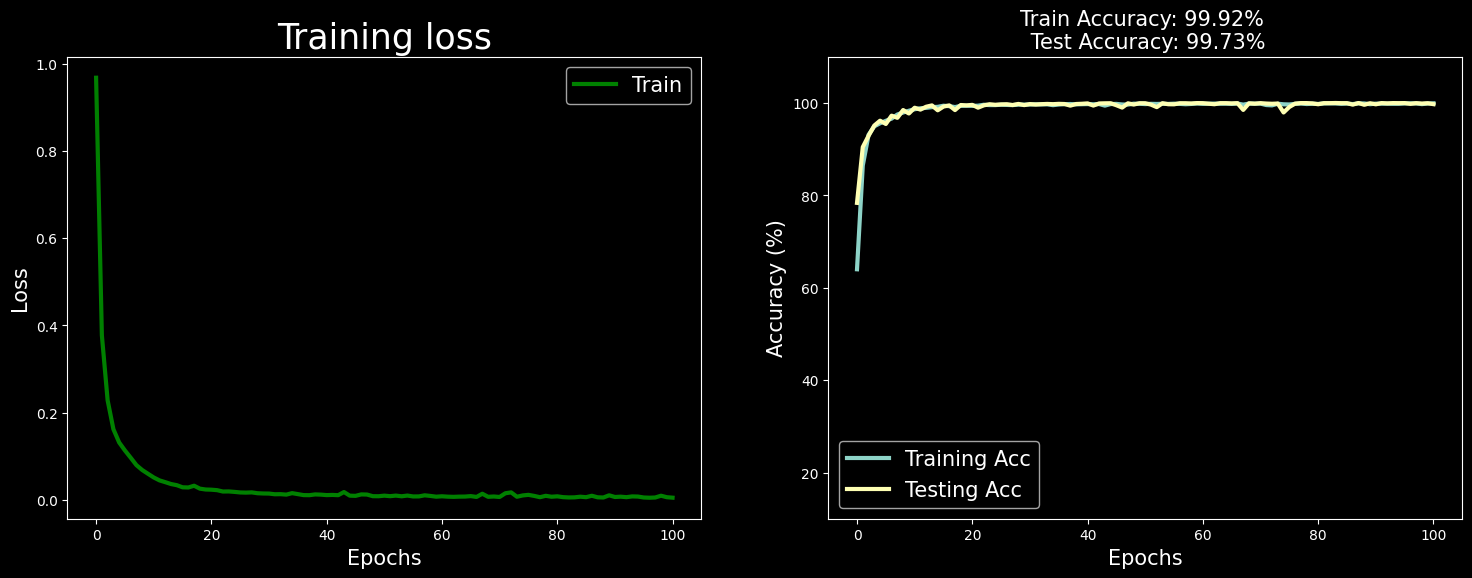

In [43]:
fig,ax = plt.subplots(1,2,figsize=(18,6))

ax[0].plot(losses,'g', lw = 3)
ax[0].set_xlabel('Epochs', fontsize = 15)
ax[0].set_ylabel('Loss', fontsize = 15)
ax[0].legend(['Train','Test'], fontsize = 15)
ax[0].set_title('Training loss', fontsize = 25)

ax[1].plot(trainAcc,label='Training Acc', lw =3)
ax[1].plot(testAcc,label='Testing Acc', lw = 3)
ax[1].set_xlabel('Epochs', fontsize = 15)
ax[1].set_ylabel('Accuracy (%)', fontsize = 15)
ax[1].set_ylim([10,110])
ax[1].set_title(f'Train Accuracy: {trainAcc[-1]:.2f}% \n Test Accuracy: {testAcc[-1]:.2f}%', fontsize = 15)
ax[1].legend(fontsize = 15)

plt.show()